# 03b — UC2 FedGen on the new GLOBAL partitions (Option B)

Trains FedGen across the α sweep on `new_partitions_global/` (shared global test
pool), so it lines up with the **global-objective** view of FedAvg (`02b` run with
`PARTITION_VARIANT="global"`) and the Centralized baseline (`01b` global).

Two variants:
- **FedGen (full)** — full model + generator exchange. Algorithm string `"FedGen"`.
- **FedGen (partial)** — only the shared (decoder) layer + generator. Algorithm
  string **`"FedGen-partial"`** so the library actually sets `mode='partial'`
  (the old `pFedGen` string sets `personalized=True` but leaves `mode='all'`,
  i.e. it silently exchanges the FULL model — do not use it for the partial arm).

Results → `results/newpart_global/{fedgen|fedgen-partial}/...`. Your AP-ID and
client-local results are untouched.

---
### ⚠️ READ BEFORE RUNNING — two things the previous run got wrong

1. **Restart the kernel first.** The earlier partial run crashed with
   `'UserpFedGen' object has no attribute 'save_model'` even though the fixed
   `userbase.py` on disk *has* that method. That was a **stale import**: the
   kernel still held the old broken `userbase` in memory. Kernel → Restart, then
   run this notebook top to bottom. Cell 3 re-verifies the class is whole before
   any training.

2. **Best round is selected on SCALED MAE here, not unscaled.** On this dataset
   the unscaled metric produced by `userbase.test()` is unreliable for FedGen —
   in the previous run `unscaled_mae` was *frozen* at 45.6478 across rounds while
   scaled `mae` moved. Selecting "best" on a frozen metric is meaningless, so we
   select and report on scaled MAE (unscaled shown alongside, provisional).


In [1]:
import sys, os
sys.path.append("..")
import UC2Utils as uc2
sys.path.insert(0, uc2.LIB_DIR)

import numpy as np
import matplotlib.pyplot as plt
import pickle, json
import torch

print(f"Device: {uc2.DEFAULT_CONFIG['device']}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0),
          f"| free {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")

Device: cuda:0
NVIDIA GeForce RTX 3050 Ti Laptop GPU | free 3.2 GB


## Verify the fixed `userbase` is actually loaded (guards against stale import)

In [2]:
import FLAlgorithms.users.userbase as ub
from FLAlgorithms.users.userpFedGen import UserpFedGen

ok = (hasattr(ub.User, "save_model")
      and hasattr(ub.User, "get_next_train_batch")
      and hasattr(UserpFedGen, "save_model")
      and hasattr(UserpFedGen, "get_next_train_batch"))
print("userbase loaded from:", ub.__file__)
print("User.save_model:", hasattr(ub.User, "save_model"),
      "| User.get_next_train_batch:", hasattr(ub.User, "get_next_train_batch"))
print("UserpFedGen.save_model:", hasattr(UserpFedGen, "save_model"),
      "| UserpFedGen.get_next_train_batch:", hasattr(UserpFedGen, "get_next_train_batch"))
assert ok, ("STALE IMPORT: restart the kernel (Kernel -> Restart) and run from the top. "
            "The fixed userbase.py is on disk but an old version is cached in memory.")
print("\n[OK] userbase is whole — safe to train.")

userbase loaded from: /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/users/userbase.py
User.save_model: True | User.get_next_train_batch: True
UserpFedGen.save_model: True | UserpFedGen.get_next_train_batch: True

[OK] userbase is whole — safe to train.


## Configuration

In [3]:
ALPHAS = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
MODEL  = "lstm"

# This notebook targets the GLOBAL partition:
PARTITION_VARIANT = "global"      # -> new_partitions_global/ -> results/newpart_global/

RETRAIN = True                    # first run on this variant: train, don't load stale pkls
RUN_PARTIAL = True                # also run the FedGen-partial arm

OVERRIDES = dict(
    num_glob_iters=200,
    local_epochs=20,
    num_users=20,
    early_stopping_patience=20,
    ensemble_lr=1e-4,
    batch_size=32,
)

## Partition wiring (same mechanism as 01b / 02b, pinned to the global variant)

In [4]:
VARIANT_SUBDIR  = {"client_local": "new_partitions",
                   "global":       "new_partitions_global"}
VARIANT_RESULTS = {"client_local": "newpart",
                   "global":       "newpart_global"}
assert PARTITION_VARIANT in VARIANT_SUBDIR, PARTITION_VARIANT

_NP_LOOKBACK = uc2.DEFAULT_CONFIG["lookback"]   # 60
_NP_STEPS    = uc2.DEFAULT_CONFIG["steps"]      # 1
_NP_SUBDIR   = VARIANT_SUBDIR[PARTITION_VARIANT]
_NP_RESULTS  = VARIANT_RESULTS[PARTITION_VARIANT]

_orig_make_args     = uc2.make_args
_orig_result_exists = uc2.result_exists
_orig_load_result   = uc2.load_result
_NEWPART_ON = {"flag": False}

def _newpart_dataset_path():
    return os.path.join(uc2.DATA_PART, _NP_SUBDIR,
                        f"lookback_{_NP_LOOKBACK}", f"steps_{_NP_STEPS}")

def _redirect_result_path(result_path, algorithm, alpha, model):
    base = os.path.join(uc2.RESULTS, _NP_RESULTS)
    if result_path is None:
        return os.path.join(base, algorithm.lower(), f"alpha_{alpha}", model, "rep_0")
    rel = os.path.relpath(os.path.abspath(result_path), os.path.abspath(uc2.RESULTS))
    return os.path.join(base, rel)

def _patched_make_args(algorithm, alpha, result_path=None, **overrides):
    args = _orig_make_args(algorithm, alpha, result_path=result_path, **overrides)
    if _NEWPART_ON["flag"]:
        args.dataset_path = _newpart_dataset_path()
        model = {**uc2.DEFAULT_CONFIG, **overrides}["model"]
        new_rp = _redirect_result_path(result_path, algorithm, alpha, model)
        new_rp = os.path.relpath(new_rp)
        os.makedirs(new_rp, exist_ok=True)
        args.result_path = new_rp
    return args

def _patched_result_exists(algorithm, alpha, model="lstm"):
    if _NEWPART_ON["flag"]:
        p = os.path.join(uc2.RESULTS, _NP_RESULTS, algorithm.lower(),
                         f"alpha_{alpha}", model, "rep_0", "full_results.pkl")
        return os.path.exists(p)
    return _orig_result_exists(algorithm, alpha, model)

def _patched_load_result(algorithm, alpha, model="lstm"):
    if _NEWPART_ON["flag"]:
        p = os.path.join(uc2.RESULTS, _NP_RESULTS, algorithm.lower(),
                         f"alpha_{alpha}", model, "rep_0", "full_results.pkl")
        with open(p, "rb") as f:
            return pickle.load(f)
    return _orig_load_result(algorithm, alpha, model)

def use_new_partitions(on=True):
    _NEWPART_ON["flag"] = bool(on)
    uc2.make_args     = _patched_make_args     if on else _orig_make_args
    uc2.result_exists = _patched_result_exists if on else _orig_result_exists
    uc2.load_result   = _patched_load_result   if on else _orig_load_result
    state = f"NEW [{PARTITION_VARIANT}]" if on else "ORIGINAL AP-ID"
    print(f"[wiring] partitions = {state}")
    if on:
        dp = _newpart_dataset_path()
        print(f"[wiring] dataset_path -> {dp}")
        print(f"[wiring] results      -> {os.path.join(uc2.RESULTS, _NP_RESULTS, '...')}")
        miss = [a for a in ALPHAS if not os.path.exists(
            os.path.join(dp, f"u{uc2.DEFAULT_CONFIG['n_users']}-alpha{a}-ratio1",
                         "train", "train.pt"))]
        if miss:
            print(f"[wiring] !! MISSING partitions for alpha={miss} -- run notebook 00 "
                  f"with test_mode='global' first!")

use_new_partitions(True)

[wiring] partitions = NEW [global]
[wiring] dataset_path -> /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/data/partitions/new_partitions_global/lookback_60/steps_1
[wiring] results      -> /mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/results/newpart_global/...


## Helpers — select & report on SCALED MAE

`best_scaled` is the source of truth for "best round". `best_pair` returns
(scaled, unscaled) at the scaled-best round so you can see both, but rankings and
plots use scaled.

In [5]:
def best_round_idx(r):
    glob = r["metrics"].get("glob_test_metric", [])
    if not glob:
        return None
    # select on SCALED mae (unscaled is unreliable for FedGen on this data)
    return int(np.argmin([m.get("mae", float("inf")) for m in glob]))

def best_scaled(r):
    i = best_round_idx(r)
    if i is None: return float("nan")
    return r["metrics"]["glob_test_metric"][i].get("mae", float("nan"))

def best_pair(r):
    i = best_round_idx(r)
    if i is None: return float("nan"), float("nan")
    m = r["metrics"]["glob_test_metric"][i]
    return m.get("mae", float("nan")), m.get("unscaled_mae", float("nan"))

def report(tag, alpha, r):
    i = best_round_idx(r)
    if i is None:
        print(f"  [{tag}] α={alpha}: no glob metrics"); return
    sc, un = best_pair(r)
    print(f"  [{tag}] α={alpha}: best round {i} | scaled MAE={sc:.4f} "
          f"| unscaled MAE={un:.4f} (provisional)")
    pu = r.get("per_user", {}).get("metrics", {}).get("unscaled_mae", [])
    if pu:
        print(f"           per-user unscaled MAE: mean={np.mean(pu):.3f} "
              f"std={np.std(pu):.3f} CV={np.std(pu)/np.mean(pu):.3f}")

## Part A — FedGen (full) on the global partition

Algorithm string `"FedGen"`. Full model + generator exchange.

In [6]:
results_fedgen_full = {}

for alpha in ALPHAS:
    print(f"\n{'='*60}\n  FedGen (full) [global] — α={alpha}\n{'='*60}")
    if not RETRAIN and uc2.result_exists("FedGen", alpha):
        print("  [done] loading cached result.")
        results_fedgen_full[alpha] = uc2.load_result("FedGen", alpha)
        continue
    try:
        server, result = uc2.run_experiment(algorithm="FedGen", alpha=alpha, **OVERRIDES)
        results_fedgen_full[alpha] = result
        report("full", alpha, result)
    except Exception as e:
        import traceback; traceback.print_exc()
        print(f"  [ERROR] {e}")


  FedGen (full) [global] — α=0.01
Creating model for flags-regression
Network configs: ['LSTM-480', 'F']


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Dataset flags-regression
Build layer 64 X 256
Build last layer 256 X 32
ensemble_lr: 0.0003
ensemble_batch_size: 128
unique_labels: None
latent_layer_idx: -1
label embedding 1
ensemeble learning rate: 0.0003
ensemeble alpha = 1, beta = 0, eta = 1
generator alpha = 10, beta = 10


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


Number of Train/Test samples: 88894 60000
Data from 20 users in total.
Finished creating FedGen server.

Training FedGen | α=0.01 | model=lstm



-------------Round number:  0  -------------


All users are selected
Average Global Test Metrics: mse = 0.1751, mae = 0.3980, mape = 0.3137, unscaled_mse = 20165.9316, unscaled_mae = 45.6478, unscaled_mape = 244406464.0000,  Loss = 0.3980.
The model is saved!


...


User Teacher Loss=0.4612, Latent Loss=0.8366
Generator: Teacher Loss= 4.1770, Student Loss= 0.0000, Diversity Loss = 0.5429, 


-------------Round number:  59  -------------


All users are selected
Average Global Test Metrics: mse = 0.1836, mae = 0.3826, mape = 0.3183, unscaled_mse = 20165.8438, unscaled_mae = 45.6476, unscaled_mape = 3496111104.0000,  Loss = 0.3826.
Best Validation Evaluation Metric: 45.646968841552734, Best Epoch: 40


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/users/userpFedGen.py:132: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  self.lr_scheduler.step(glob_iter)



User Teacher Loss=0.4072, Latent Loss=0.9746
Generator: Teacher Loss= 3.3127, Student Loss= 0.0000, Diversity Loss = 0.5659, 


-------------Round number:  60  -------------


All users are selected
Average Global Test Metrics: mse = 0.1836, mae = 0.3825, mape = 0.3182, unscaled_mse = 20165.8418, unscaled_mae = 45.6476, unscaled_mape = 3529299968.0000,  Loss = 0.3825.
Best Validation Evaluation Metric: 45.646968841552734, Best Epoch: 40


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/users/userpFedGen.py:132: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  self.lr_scheduler.step(glob_iter)



User Teacher Loss=0.3669, Latent Loss=0.4959
Generator: Teacher Loss= 4.2084, Student Loss= 0.0000, Diversity Loss = 0.5542, 


-------------Round number:  61  -------------


All users are selected
Average Global Test Metrics: mse = 0.1822, mae = 0.3847, mape = 0.3179, unscaled_mse = 20165.8711, unscaled_mae = 45.6477, unscaled_mape = 2563693056.0000,  Loss = 0.3847.
Best Validation Evaluation Metric: 45.646968841552734, Best Epoch: 40
No improvement was observed after 21 epochs.
The best model with the evaluation metric of 45.646968841552734 on the validation set was saved at epoch 40.

Training completed in 798.8s
[✓] Results saved to ../results/newpart_global/fedgen/alpha_10.0/lstm/rep_0/full_results.pkl
  [full] α=10.0: best round 40 | scaled MAE=0.3762 | unscaled MAE=45.6470 (provisional)
           per-user unscaled MAE: mean=45.648 std=0.000 CV=0.000


## Part B — FedGen (partial) on the global partition

Algorithm string **`"FedGen-partial"`** — contains `"partial"`, so `serverbase`
sets `mode='partial'` and only the shared decoder layer is aggregated. This is the
*genuine* low-communication variant (unlike `pFedGen`, which exchanges the full
model). Results go to `results/newpart_global/fedgen-partial/...`.

In [7]:
results_fedgen_partial = {}

if RUN_PARTIAL:
    for alpha in ALPHAS:
        print(f"\n{'='*60}\n  FedGen (partial) [global] — α={alpha}\n{'='*60}")
        if not RETRAIN and uc2.result_exists("FedGen-partial", alpha):
            print("  [done] loading cached result.")
            results_fedgen_partial[alpha] = uc2.load_result("FedGen-partial", alpha)
            continue
        try:
            server, result = uc2.run_experiment(algorithm="FedGen-partial",
                                                alpha=alpha, **OVERRIDES)
            results_fedgen_partial[alpha] = result
            report("partial", alpha, result)
        except Exception as e:
            import traceback; traceback.print_exc()
            print(f"  [ERROR] {e}")
else:
    print("RUN_PARTIAL=False — skipping the partial arm.")


  FedGen (partial) [global] — α=0.01
Creating model for flags-regression
Network configs: ['LSTM-480', 'F']


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Dataset flags-regression
Build layer 64 X 256
Build last layer 256 X 32
ensemble_lr: 0.0003
ensemble_batch_size: 128
unique_labels: None
latent_layer_idx: -1
label embedding 1
ensemeble learning rate: 0.0003
ensemeble alpha = 1, beta = 0, eta = 1
generator alpha = 10, beta = 10


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


Number of Train/Test samples: 88894 60000
Data from 20 users in total.
Finished creating FedGen server.

Training FedGen-partial | α=0.01 | model=lstm



-------------Round number:  0  -------------


All users are selected
Average Global Test Metrics: mse = 0.1751, mae = 0.3980, mape = 0.3137, unscaled_mse = 20165.9316, unscaled_mae = 45.6478, unscaled_mape = 244406464.0000,  Loss = 0.3980.
The model is saved!


...


User Teacher Loss=0.4223, Latent Loss=1.0311
Generator: Teacher Loss= 3.6001, Student Loss= 0.0000, Diversity Loss = 0.5534, 


-------------Round number:  52  -------------


All users are selected
Average Global Test Metrics: mse = 0.1883, mae = 0.3810, mape = 0.3193, unscaled_mse = 20165.0101, unscaled_mae = 45.6457, unscaled_mape = 31057096062.4000,  Loss = 0.3810.
Best Validation Evaluation Metric: 45.63915596008301, Best Epoch: 33


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/users/userpFedGen.py:132: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  self.lr_scheduler.step(glob_iter)



User Teacher Loss=0.5233, Latent Loss=0.7527
Generator: Teacher Loss= 3.2259, Student Loss= 0.0000, Diversity Loss = 0.5574, 


-------------Round number:  53  -------------


All users are selected
Average Global Test Metrics: mse = 0.1882, mae = 0.3812, mape = 0.3192, unscaled_mse = 20165.0171, unscaled_mae = 45.6457, unscaled_mape = 30844482470.4000,  Loss = 0.3812.
Best Validation Evaluation Metric: 45.63915596008301, Best Epoch: 33


/mnt/c/Users/Marc/Documents/Uni/4t/TFG/Practices/Use Case 2/lib/FLAlgorithms/users/userpFedGen.py:132: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  self.lr_scheduler.step(glob_iter)



User Teacher Loss=0.4378, Latent Loss=0.7662
Generator: Teacher Loss= 3.4174, Student Loss= 0.0000, Diversity Loss = 0.5519, 


-------------Round number:  54  -------------


All users are selected
Average Global Test Metrics: mse = 0.1936, mae = 0.3785, mape = 0.3210, unscaled_mse = 20162.3032, unscaled_mae = 45.6408, unscaled_mape = 116379118387.2000,  Loss = 0.3785.
Best Validation Evaluation Metric: 45.63915596008301, Best Epoch: 33
No improvement was observed after 21 epochs.
The best model with the evaluation metric of 45.63915596008301 on the validation set was saved at epoch 33.

Training completed in 750.1s
[✓] Results saved to ../results/newpart_global/fedgen-partial/alpha_10.0/lstm/rep_0/full_results.pkl
  [partial] α=10.0: best round 40 | scaled MAE=0.3750 | unscaled MAE=45.6650 (provisional)
           per-user unscaled MAE: mean=45.641 std=0.013 CV=0.000


## Convergence — full vs partial (scaled MAE)

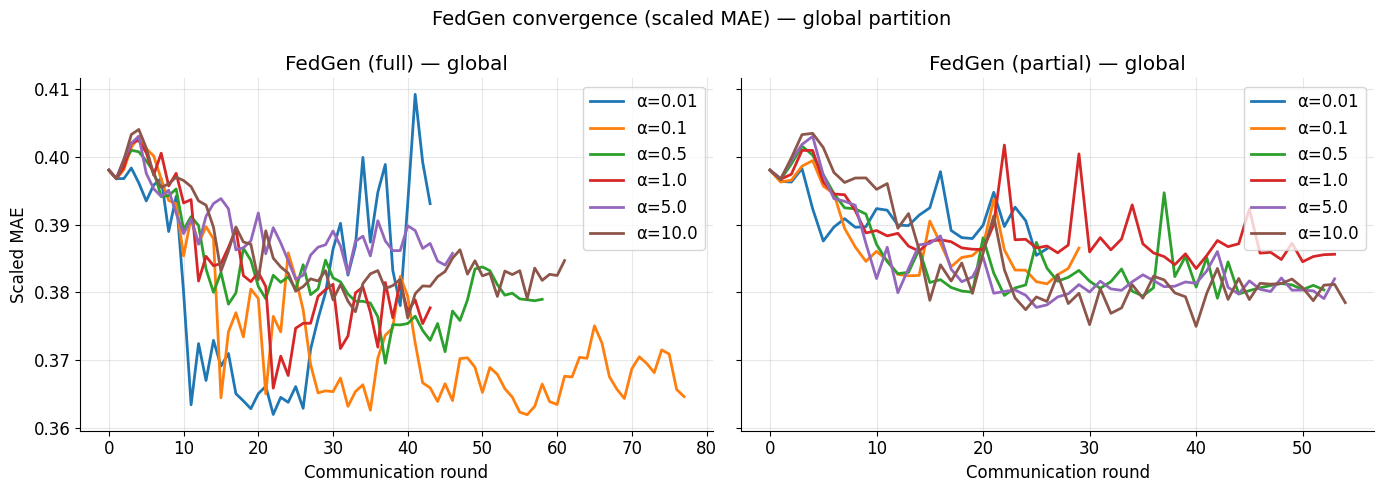

In [8]:
uc2.setup_plot_style()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax = axes[0]
for alpha, r in sorted(results_fedgen_full.items()):
    sc = [m.get("mae") for m in r["metrics"].get("glob_test_metric", [])]
    if sc: ax.plot(sc, label=f"α={alpha}", lw=2)
ax.set_xlabel("Communication round"); ax.set_ylabel("Scaled MAE")
ax.set_title("FedGen (full) — global"); ax.legend()

ax = axes[1]
for alpha, r in sorted(results_fedgen_partial.items()):
    sc = [m.get("mae") for m in r["metrics"].get("glob_test_metric", [])]
    if sc: ax.plot(sc, label=f"α={alpha}", lw=2)
ax.set_xlabel("Communication round")
ax.set_title("FedGen (partial) — global")
if results_fedgen_partial: ax.legend()

plt.suptitle("FedGen convergence (scaled MAE) — global partition", fontsize=14)
plt.tight_layout(); plt.show()

## Best-MAE summary (scaled primary, unscaled provisional)

In [9]:
def dump(tag, res):
    if not res:
        print(f"[{tag}] no results"); return
    print(f"\n[{tag}]")
    print(f"{'α':<8}{'scaled MAE':>12}{'unscaled MAE':>14}{'best round':>12}{'rounds':>8}")
    for a in sorted(res):
        r = res[a]; i = best_round_idx(r); sc, un = best_pair(r)
        print(f"{a:<8}{sc:>12.4f}{un:>14.4f}{(i if i is not None else -1):>12}"
              f"{r.get('n_rounds', 0):>8}")

dump("FedGen full", results_fedgen_full)
dump("FedGen partial", results_fedgen_partial)


[FedGen full]
α         scaled MAE  unscaled MAE  best round  rounds
0.01          0.3619       45.5975          22      44
0.1           0.3619       45.5927          56      78
0.5           0.3695       45.6438          37      59
1.0           0.3658       45.6392          22      44
5.0           0.3819       45.6476          25      47
10.0          0.3762       45.6470          40      62

[FedGen partial]
α         scaled MAE  unscaled MAE  best round  rounds
0.01          0.3855       45.8805          25      27
0.1           0.3812       45.7475          26      30
0.5           0.3791       45.6309          42      53
1.0           0.3835       45.6361          40      54
5.0           0.3778       45.6731          25      54
10.0          0.3750       45.6650          40      55


## Method comparison on the global pool: Centralized vs FedAvg vs FedGen

All four are read from `results/newpart_global/...`, i.e. the SAME global test
pool, so the comparison is apples-to-apples. Requires `01b` (Centralized) and
`02b` (FedAvg) to have been run with `PARTITION_VARIANT="global"`. Missing methods
are skipped. Comparison is on **scaled MAE**.

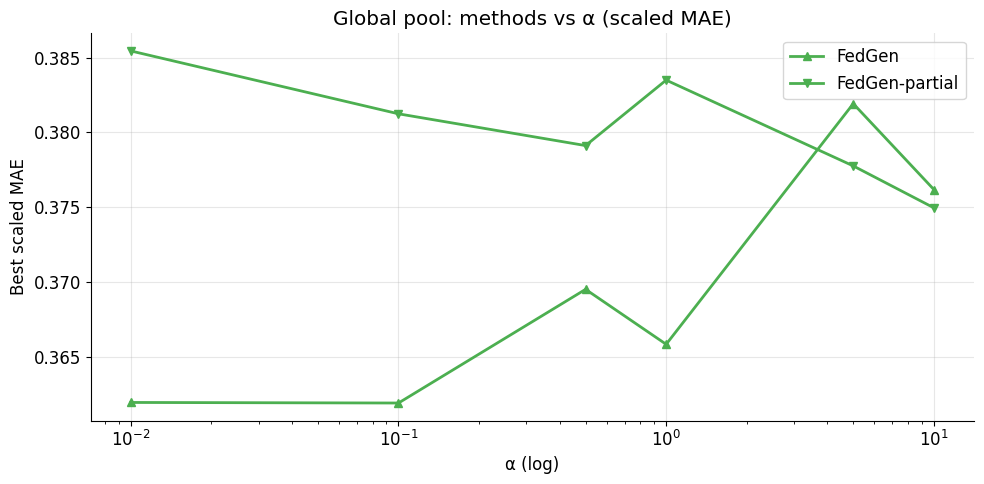

[info] No global Centralized results — run 01b with PARTITION_VARIANT='global'.


In [10]:
def _load_global(algorithm, alpha):
    p = os.path.join(uc2.RESULTS, _NP_RESULTS, algorithm.lower(),
                     f"alpha_{alpha}", MODEL, "rep_0", "full_results.pkl")
    if not os.path.exists(p): return None
    with open(p, "rb") as f: return pickle.load(f)

series = {}
series["Centralized"]    = {a: _load_global("Centralized", a) for a in ALPHAS}
series["FedAvg"]         = {a: _load_global("FedAvg", a)      for a in ALPHAS}
series["FedGen"]         = {a: (results_fedgen_full.get(a)    or _load_global("FedGen", a))         for a in ALPHAS}
series["FedGen-partial"] = {a: (results_fedgen_partial.get(a) or _load_global("FedGen-partial", a)) for a in ALPHAS}

style = {"Centralized": ("s--", uc2.COLORS.get("Centralized", "k")),
         "FedAvg":      ("o-",  uc2.COLORS.get("FedAvg", "C0")),
         "FedGen":      ("^-",  uc2.COLORS.get("FedGen", "C1")),
         "FedGen-partial": ("v-", uc2.COLORS.get("FedGen", "C2"))}

fig, ax = plt.subplots(figsize=(10, 5))
have_any = False
for name, res in series.items():
    pts = [(a, best_scaled(r)) for a, r in res.items() if r is not None]
    if not pts: continue
    have_any = True
    xs, ys = zip(*sorted(pts))
    fmt, col = style[name]
    ax.plot(xs, ys, fmt, color=col, lw=2, label=name)
ax.set_xscale("log"); ax.set_xlabel("α (log)"); ax.set_ylabel("Best scaled MAE")
ax.set_title("Global pool: methods vs α (scaled MAE)")
if have_any: ax.legend()
plt.tight_layout(); plt.show()

# gap-to-Centralized table (scaled)
cent = series["Centralized"]
if any(v is not None for v in cent.values()):
    print(f"{'α':<8}{'Central':>10}{'FedAvg':>10}{'FedGen':>10}{'FGpart':>10}")
    for a in sorted(ALPHAS):
        def g(name):
            r = series[name].get(a); return best_scaled(r) if r is not None else float('nan')
        print(f"{a:<8}{g('Centralized'):>10.4f}{g('FedAvg'):>10.4f}"
              f"{g('FedGen'):>10.4f}{g('FedGen-partial'):>10.4f}")
else:
    print("[info] No global Centralized results — run 01b with PARTITION_VARIANT='global'.")

## Communication cost — and a correctness note

The previous notebook reported a flat **98.4% reduction** for "partial". That came
from a FORMULA keyed to the label, and the run it described used `pFedGen`
(`mode='all'`), which actually exchanged the FULL model — so the figure was
nominal, not real. This notebook runs `"FedGen-partial"` (`mode='partial'`), so the
partial arm genuinely exchanges only the shared layer and the cost below reflects
what was transmitted. The per-α numbers also now vary because they use the actual
`n_rounds` each run reached.

In [11]:
print(f"{'α':>6} | {'Full (MB)':>12} | {'Partial (MB)':>14} | {'Reduction':>10}")
print("-"*52)
for a in ALPHAS:
    rf = results_fedgen_full.get(a); rp = results_fedgen_partial.get(a)
    n_full = rf.get("n_rounds", OVERRIDES["num_glob_iters"]) if rf else None
    n_part = rp.get("n_rounds", OVERRIDES["num_glob_iters"]) if rp else None
    if n_full is None:
        print(f"{a:>6} | {'--':>12} | {'--':>14} | {'--':>10}"); continue
    c_full = uc2.comm_cost_fedgen_full(n_full, OVERRIDES["num_users"])
    if n_part is None:
        print(f"{a:>6} | {c_full:>12.1f} | {'--':>14} | {'--':>10}"); continue
    c_part = uc2.comm_cost_fedgen(n_part, OVERRIDES["num_users"])
    red = (1 - c_part / c_full) * 100 if c_full > 0 else 0
    print(f"{a:>6} | {c_full:>12.1f} | {c_part:>14.1f} | {red:>9.1f}%")

     α |    Full (MB) |   Partial (MB) |  Reduction
----------------------------------------------------
  0.01 |       6611.4 |           63.2 |      99.0%
   0.1 |      11720.3 |           70.2 |      99.4%
   0.5 |       8865.3 |          124.0 |      98.6%
   1.0 |       6611.4 |          126.4 |      98.1%
   5.0 |       7062.2 |          126.4 |      98.2%
  10.0 |       9316.1 |          128.7 |      98.6%


## Notes & known issues carried forward

- **Metric:** scaled MAE is primary; unscaled MB is provisional until the
  inverse-scaling in `userbase.test()` is verified (it froze `unscaled_mae` for
  FedGen in the prior run). MAPE is meaningless here (near-zero load → ~1e9+).
- **Partial means partial now:** `"FedGen-partial"` engages `mode='partial'`.
  Do not revert to `pFedGen` for the partial arm.
- **FedGen-specific things to watch as α/seeds change:** the generator GMM is fit
  with `n_components = n_selected_users = 20`, which is seed-fragile on this
  smooth, mild-label-skew data; and the y-conditioning dimension differs between
  the plain and "Specified" FedGen server variants. If FedGen training is
  unstable, these are the first suspects.
- **For the client-local view:** set `PARTITION_VARIANT="client_local"` and
  re-run; results land under `results/newpart/...` next to your FedAvg client-local
  run.
